## Lab 3: Differential Diagnosis and Conditional Expectation

<font color = "red">

### Kruthi Jayendra, Shawn June, and Sally Linkenauger 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')

ModuleNotFoundError: No module named 'graphviz'


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [ ]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


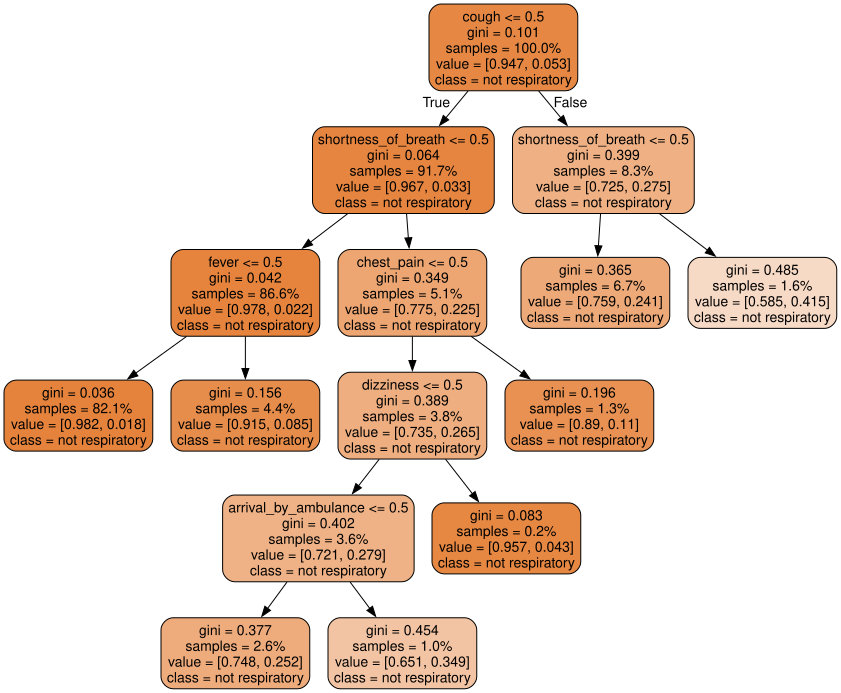

In [ ]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

## Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

When only taking into account symptom presence (the question does not say to take into account symptom absence):

For this data set, the combination of cough and shortness of breath make respiratory disease most likely. Having dizziness and shortness of breath makes it least likely you have a respiratory disease (but coming from a very small percentage of the whole sample).  

When taking into account the absence of symptom in addition to symptom presence:
The combination of cough and shortness of breath makes a respiratory disease most likely explanation, with a probability of approximately 0.415. The least likely combination is no cough, no shortness of breath, and no fever, with a respiratory-disease probability of approximately 0.018.

This shows that both the presence and absence of symptoms provide useful information. As the tree learns more about a patient's symptoms, it updates the estimated probability of a respiratory diagnosis. 


## Which variables does the tree exploit? 
The tree uses the variables "cough", "shortness of breath", "fever", "chest pain", "dizziness" and "arrival by ambulance".



## Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information. 

Before looking at how the tree chooses its splits, it helps to separate two ideas: what the tree is telling us and how it decides where to split. The tree starts with the overall probability of respiratory disease. Each symptom question then narrows the patients into a more specific group, so the probability is updated using the information learned along that path. This is conditional updating. Gini impurity is then used to help determine which symptom creates the most useful next split. We go into more detail below:

What is conditional updating with reference to this analysis:

Let us operationally define conditional updating as the process of revising our probabilities by grouping based on conditions imposed by predictive, classifying variables. By adding a new classification variable to our tree, we split our tree based on that classification, which separates a portion of our sample that meets a specific condition (symptom present or absent). That subgroup has a different probability estimate than the main group because its members share the same condition caused by the variable. This process repeats each time we add a variable, and the tree splits the current subgroup further, which produces an increasingly specific (and increasingly homogeneous) probability estimate at each step.

Overall, we add variables to our model that iteratively create conditional groupings that isolate those in their respective diagnostic group (step 1 of notebook: present/absent; step 2 of notebook: which diagnostic category).  As a result, we use the variables that create homogenous groupings of the dependent measure as predictors of the target outcome.  


How does the tree do this?

The tree still needs a way to decide which symptom should be used for each split. It does this by looking for symptoms that best separate patients with a respiratory diagnosis from those without one. This is measured using gini impurity. A lower gini value means a group is more homogeneous, while a higher gini value means the outcomes within the group are more mixed.

More specifically:
The tree updates using the variables with the largest impurity decrease. The goal is to achieve purity - the classification of the diagnosis into yes, no groups by using symptoms as classification variables.  A symptom that achieves purity can classify the outcome of the diagnosis into yes/no camps (hypothetically, 100% of those in the "true" cough group have the respiratory diagnosis and those that do not have the cough, do not have the diagnosis; this would be complete purity). 

The tree does this by calculating a gini: the gini quantifies the homogeneity within the present/absent groups that a variable provides. Consider one variable (A)'s true classification contains the outcome as .05 proportion "no" and .95 proportion "yes" in my outcome.  So I can say that this variable is able to sort my outcome cases by having this symptom quite well. If I multiply these values and multiply by 2 (.95 * .05 * 2 ), I get a relatively low value, .1.  This means that most people in the "yes" symptom have the diagnosis and this same yes group has very few of those without the diagnosis.  Put simply, this group is pure in terms of its uniformity of the diagnosis.  Now lets consider another variable (B) whose presence of that symptom classifies an outcome .5 (yes) and .5 (no). That grouping is less homogenous.  Half of the people with that symptom have the diagnosis and half do not have the diagnosis, so that symptom leads to groups that are less pure and does little work in explaining the diagnosis in comparison to variable A.  Consequently, its gini (.5*.5 * 2= .5) is much higher;it is more impure.  Each node that is added to the model must improve upon purity by decreasing its gini (the sum of the ginis for each child node (weighted by the sample percentage of the parent's node for which they account)).

 The decrease of impurity indicated by the weighted sum of the child nodes of the added variable suggests that this variable is doing some of the work in classifying a positive versus negative outcome.  However, the tree should not keep adding new splits forever. At some point, an additional symptom may improve the separation only slightly while making the tree much more complicated. The min_impurity_decrease parameter sets the minimum amount of improvement required before the tree is allowed to add another split.

 At the beginning of the model, the tree compares all 20 variables to determine which variable creates the largest bifurcation in the outcome variable in its child nodes, i.e., if they have that symptom, they have a higher difference between those that have the diagnosis to those that do not than in the parent node (this could also be in the node signaling the absence of the symptom, it is actually the weighted sum of these two child nodes that is tested against the parent). The winning node becomes the first node of the tree. Then, each node of the variable (yes/no) uses the portion of the sample that it contains, and tests the rest of the variables to assess the degree to which they decrease the impurity within the sample contained by that node. The variable that leads to the highest reduction of impurity is chosen as the next node, but only if it reduces impurity to a magnitude that it surpasses the minimum impurity decrease threshold. This process is iterative until none of the variables produce an impurity reduction that surpasses the minimum impurity decrease threshold (or it the tree surpasses the max_depth or min_samples_leaf also added as a free parameter).

 




## Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

### 1e-3
Lowest probability leaf= [.978, .022]
highest probability leaf = [.725, .275]

### 1e-5

lowest probability leaf = [1, 0]
highest probability leaf = [0.445, 0.555]


### 1e-7

lowest probability leaf = [1,0]
highest probability leaf =  [0.423, 0.577]

As the complexity of the tree increases, the terminal leaves that have the highest and lowest probabilities move farther apart in their constitution of positive respiratory disease cases. The lowest move towards having lesser and lesser proportions of respiratory disease.  The highest move towards having higher proportions of respiratory disease.   



</div>

min_impurity_decrease = 0.001


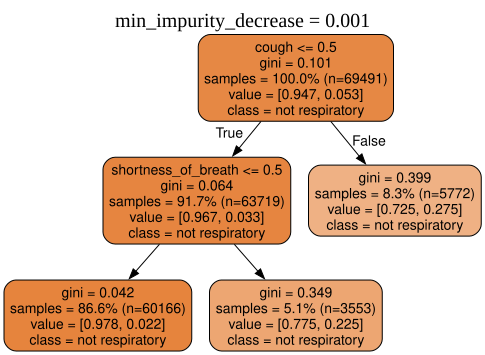

min_impurity_decrease = 1e-05


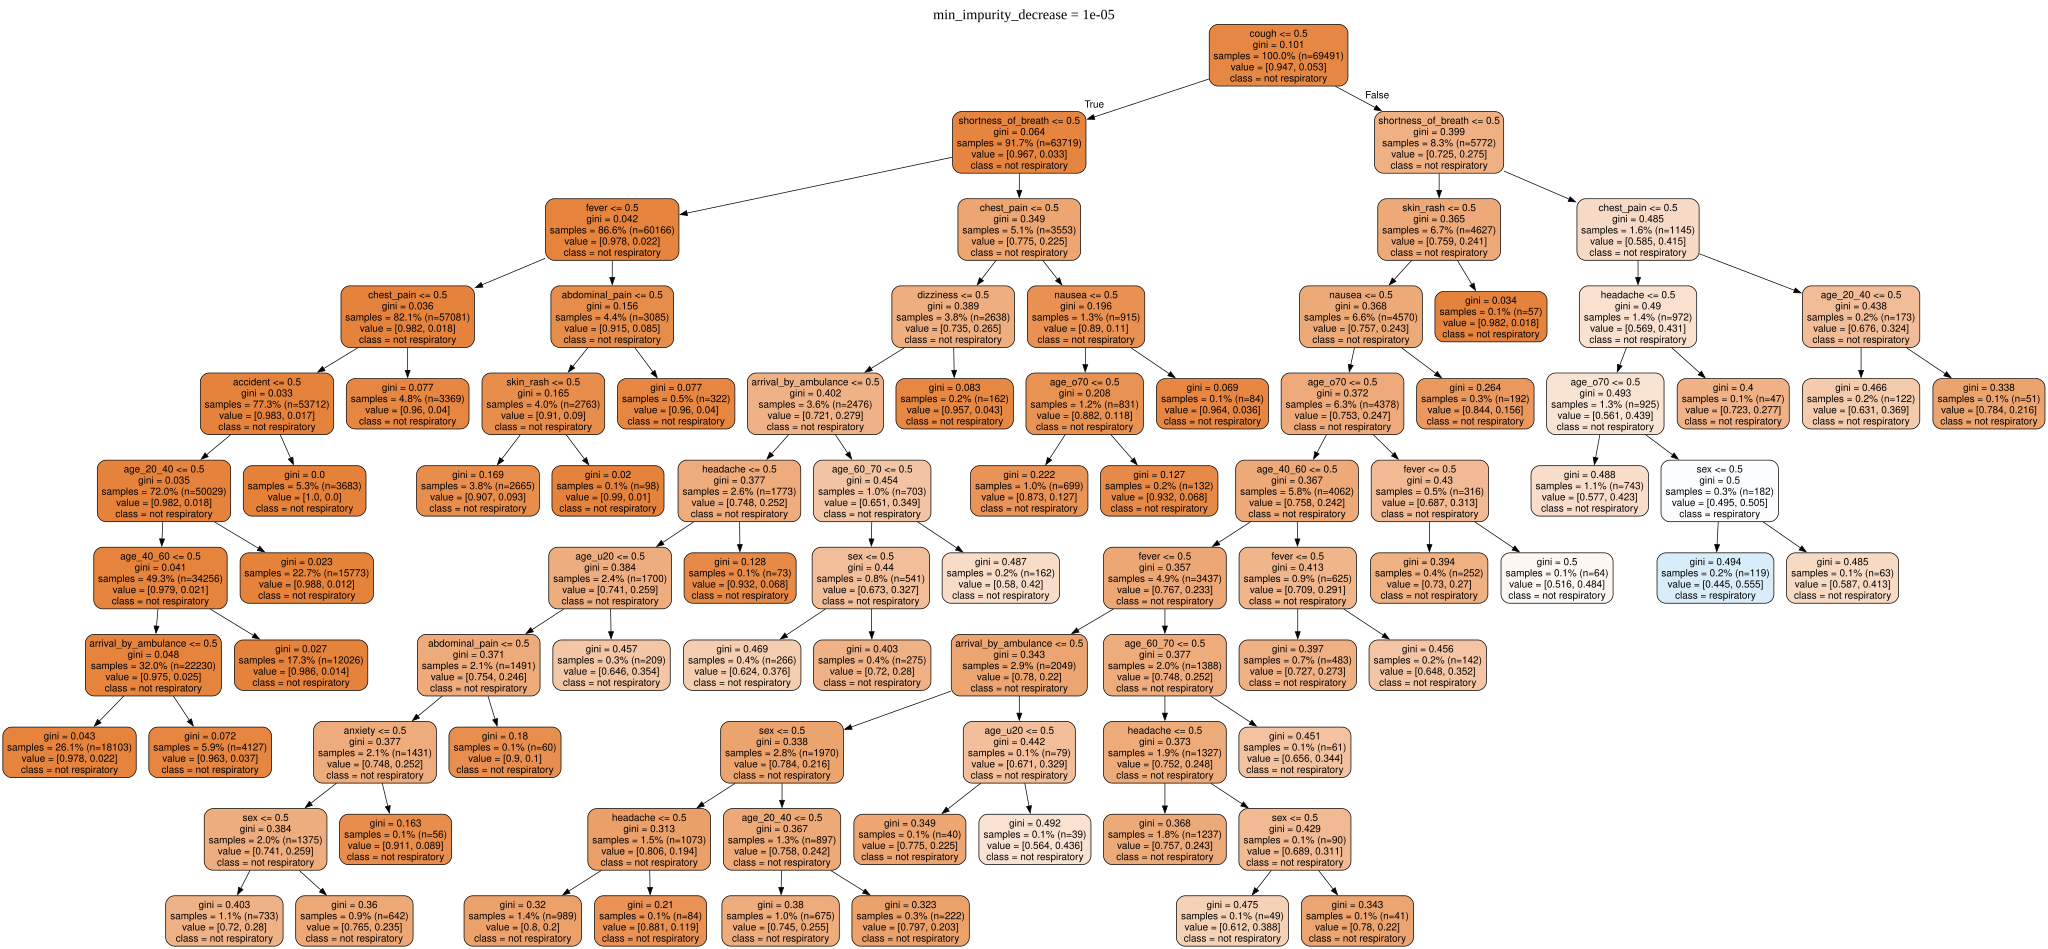

min_impurity_decrease = 1e-07


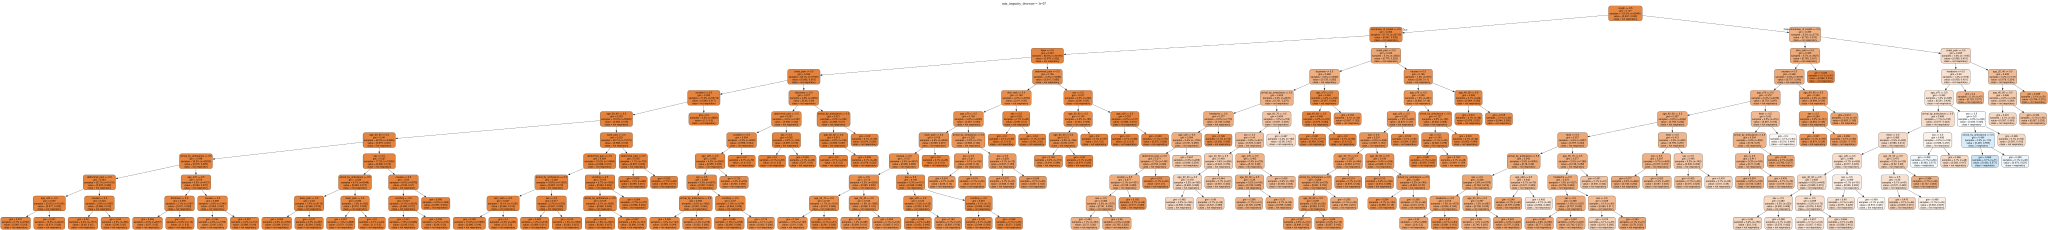

In [ ]:
# Set outcome variable:
disease = 'respiratory'

ID_list = [1e-3, 1e-5, 1e-7]

import re
from IPython.display import display

for i in ID_list:
    model = DecisionTreeClassifier(max_depth=10,
                                    min_samples_leaf=35,
                                    min_impurity_decrease=i,
                                    random_state=100)
    model.fit(X, y)

    dot_data = export_graphviz(
        model,
        out_file=None,
        feature_names=x_vars,
        class_names=outcome,
        filled=True,
        proportion=True,
        rounded=True,
    )

    # Add a title to the graph
    dot_data = dot_data.replace(
        'digraph Tree {',
        f'digraph Tree {{\nlabel="min_impurity_decrease = {i}";\nlabelloc=t;\nfontsize=20;'
    )

    # Add raw sample counts alongside the percentages
    node_samples = model.tree_.n_node_samples
    counter = {"i": 0}
    def add_count(match):
        n = node_samples[counter["i"]]
        counter["i"] += 1
        return f"{match.group(0)} (n={n})"
    dot_data = re.sub(r"samples = [\d.]+%", add_count, dot_data)

    graph = graphviz.Source(dot_data)
    print(f"min_impurity_decrease = {i}")
    display(graph)

<div class="alert alert-block alert-warning">

### Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?


None, I think the reason for this is that the number of neurological diagnoses are so rare. They make up such a small sample of the population that that node is almost completely homogeneous (pure). Reducing the impurity is a difficult task as there is so little left to reduce.  At min_impurity_decrease = 1e-3, none of the available predictors reduces impurity enough to justify another split. In other words, the tree does not identify any variables that meaningfully raise or lower the predicted probability of neurological diagnosis at this threshold. This does not mean neurological diagnoses are inherently unpredictable; it only means that the variables in this simplified dataset do not separate neurological from non-neurological cases strongly enough under these settings.

Also, it is worth considering that it could very well be that the symptoms in our analysis are not especially geared towards classifying neurological conditions. As shown in clinical research (Harsh, et al., 2025), neurological symptoms tend to manifest themselves in human behavior and thought patterns, not the obvious physical symptoms indicative of other diseases.  


Harsh, S., Rather, H. J., Dwivedi, A., Bala, A., Velladurai, P., & Anantharaman, S. (2025). The 
    Neuropsychology of Chronic Neurological Disorders: A Review of Cognitive and Emotional Impairments. Cureus, 17(10), e93642. https://doi.org/10.7759/cureus.93642



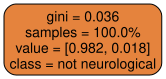

In [ ]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Minimum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

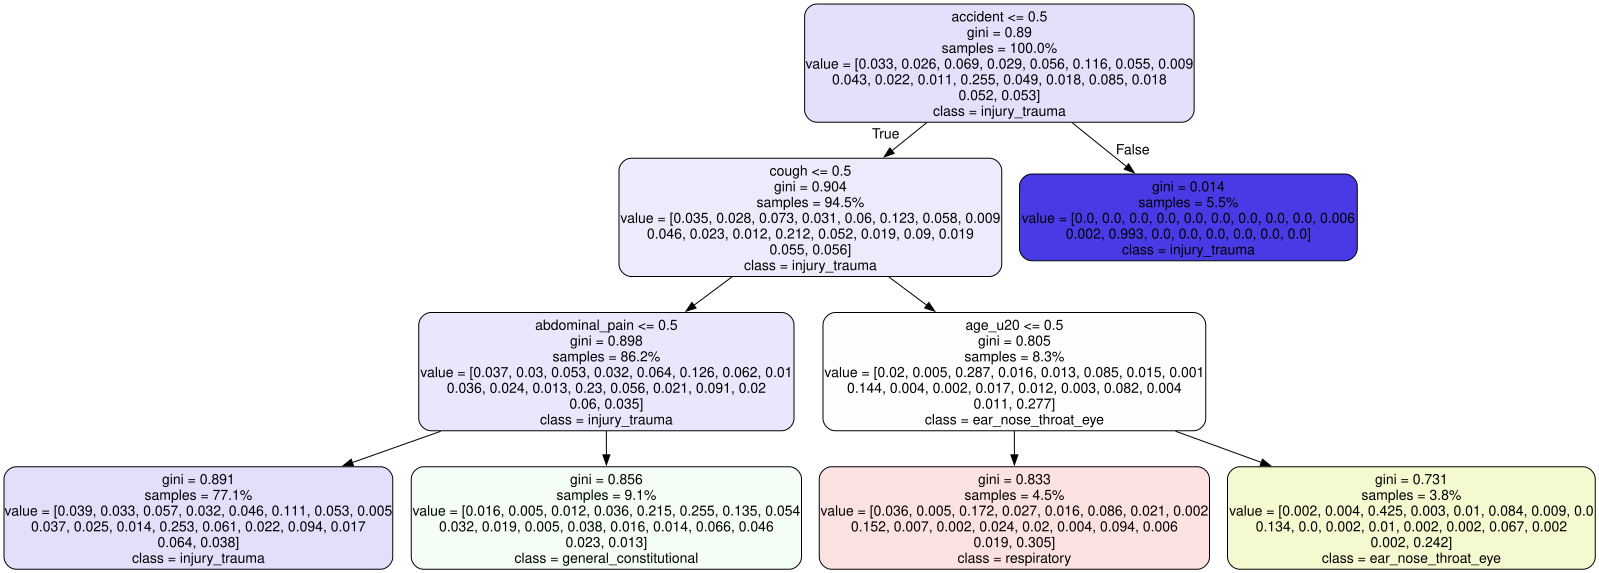

In [ ]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

### Which diseases are predicted as hard classifications in the tree? 

"Injury trauma", "General Constitutional", "Ear, nose and throat", and "Respiratory"

The tree produces two related outputs. First, it estimates a probability for each possible disease category. Second, it chooses the category with the highest probability as its single predicted label, called the hard classification. Importantly, the highest probability is not always a high probability; it may simply be the largest among several <em>more</em> uncertain options.

### For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?
Injury trauma, yes = .993

Ear, nose and throat, yes for .3, no for .5 = .425

Respiratory, yes for .3, no for .5 = .305

General constitutional, no = .255


Hard classifications may be misleading for those using the model. The probabilities vary widely across these classifications.  The probability of having an injury trauma diagnosis based on the predictor symptoms is much higher (.99) than the probability of having a general constitutional diagnosis based on the predictor symptoms (.25).  However, they both get classified definitively with a diagnostic outcome. This could cause high confidence errors in diagnoses by individuals conflating the hard classification with higher probabilities.




### Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Injury trauma has the highest predicted-class probability at approximately 0.993. The lowest predicted-class probability is actually another injury trauma terminal leaf at approximately 0.253, which is slightly lower than general constitutional at approximately 0.255. This shows that the same hard classification can be made with either very high or relatively low probability depending on the path through the tree.

### Which conditions and values are used in the tree?

Accident <= .5

Cough <= .5

Abdominal pain <= .5

Age under 20 <= .5

### Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

No one diagnostic tool is used to generate a full diagnosis.  Doctors consider a large amount of information from various sources when considering the root cause of an illness.  Each tool helps filter out alternatives using unique variability from different sources.  This tool is just one source. You could almost think of the diagnostic probabilities produced in this tool as a single parameter in another diagnostic model. 

</div>